# Part 0: Load in libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sbn
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import re
import math
import scipy
from scipy.stats import ks_2samp
from matplotlib.patches import Rectangle
import pathlib
from matplotlib import font_manager
from scipy.stats import fisher_exact
import localcider
from localcider.sequenceParameters import SequenceParameters



# Setup the fonts
fonts_path = pathlib.Path.home().joinpath('fonts') # i.e. `~/fonts` (update as needed)
font_filename = 'ARIAL.TTF'
font_path = fonts_path.joinpath(font_filename)
print(font_path)

font_manager.fontManager.addfont(str(font_path))
prop = font_manager.FontProperties(fname=font_path)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['pdf.fonttype'] = 42 # Makes text editiable
plt.rcParams['ps.fonttype'] = 42

COLOR_MAP = dict()
COLOR_MAP['A']         = '#8c8c8c'
COLOR_MAP['CHNQST']    = '#077a15'
COLOR_MAP['DE']        = '#e23a36'
COLOR_MAP['FWY']       = '#f58220'
COLOR_MAP['G']         = '#86bd8d'
COLOR_MAP['ILMV']      = '#231f20'
COLOR_MAP['KR']        = '#1725c2'
COLOR_MAP['P']         = '#c25fc9'


# Using the global color map, we convert the colormap of amino acid
# groups, to a map against individual amino acids. This
# serves as our internal color map which is used for styling.
aacolor_map=dict()
for amino_acids in COLOR_MAP:
    for amino_acid in amino_acids:
        aacolor_map[amino_acid] = COLOR_MAP[amino_acids]

/home/research/kiersten.ruff/fonts/ARIAL.TTF


# Part 1: Get and Analyze IDRs

## 1.1 - Load in all IDR information

In [2]:
humandf=pd.read_excel('../general_data/All_sapiens_IDRs_clustermap_using_centroids.xlsx')

print(humandf.isnull().any())
humandf = humandf.fillna('')

fullaccs=humandf['Uniprot'].tolist()
fullaccswnums=humandf['Uniprot w IDRnum'].tolist()
fullgeneswnums=humandf['Gene'].tolist()
fullclusternum=humandf['Cluster Number'].tolist()
fullseqlens=humandf['IDR Length'].tolist()
fullstpos=humandf['Start Pos'].tolist()
fullenpos=humandf['End Pos'].tolist()
fullproteinlength=humandf['Full Protein Length'].tolist()
fullmininterclustdist=humandf['Min Inter Clust Dist'].tolist()
fulltermini=humandf['IDR Position'].tolist()
fulllocationbyunistring=humandf['HPA Location'].tolist()
fullseqs=humandf['Sequence'].tolist()

print(humandf)


Unnamed: 0              False
Uniprot                 False
Uniprot w IDRnum        False
Gene                    False
Cluster Number          False
IDR Length              False
Start Pos               False
End Pos                 False
Full Protein Length     False
Min Inter Clust Dist    False
IDR Position            False
HPA Location             True
Sequence                False
dtype: bool
       Unnamed: 0 Uniprot Uniprot w IDRnum            Gene  Cluster Number  \
0               0  G5E9R7         G5E9R7_1  KRTAP4-16 IDR1              27   
1               1  Q9NRJ4         Q9NRJ4_1      TULP4 IDR1              17   
2               2  Q9NRJ4         Q9NRJ4_2      TULP4 IDR2               1   
3               3  Q9NRJ4         Q9NRJ4_3      TULP4 IDR3              27   
4               4  Q9NRJ4         Q9NRJ4_4      TULP4 IDR4              27   
...           ...     ...              ...             ...             ...   
24503       24503  Q7Z739         Q7Z739_2     YTHDF

## 1.2 - Load in all IDR z-score data

In [3]:
# make sure features match
myfeat=['pol-pol','pol-hyd','pol-pos','pol-neg','pol-aro','pol-ala','pol-pro','pol-gly','hyd-hyd','hyd-pos','hyd-neg','hyd-aro','hyd-ala','hyd-pro','hyd-gly','pos-pos','pos-neg','pos-aro','pos-ala','pos-pro','pos-gly','neg-neg','neg-aro','neg-ala','neg-pro','neg-gly','aro-aro','aro-ala','aro-pro','aro-gly','ala-ala','ala-pro','ala-gly','pro-pro','pro-gly','gly-gly','Frac A','Frac C','Frac D','Frac E','Frac F','Frac G','Frac H','Frac I','Frac K','Frac L','Frac M','Frac N','Frac P','Frac Q','Frac R','Frac S','Frac T','Frac V','Frac W','Frac Y','Frac K+R','Frac D+E','Frac Polar','Frac Aliphatic','Frac Aromatic','R/K Ratio','E/D Ratio','Frac Chain Expanding','FCR','NCPR','Hydrophobicity','Disorder Promoting','Iso point','PPII','A Patch','C Patch','D Patch','E Patch','F Patch','G Patch','H Patch','I Patch','K Patch','L Patch','M Patch','N Patch','P Patch','Q Patch','R Patch','S Patch','T Patch','V Patch','Y Patch','RG Frac']
print(len(myfeat))

# Load in z-scores for all human IDRs
# Made in /project/fava/work/kiersten.ruff/Collaborations/Su/2023/Library_design/map_clusters_for_all_human_IDRs.ipynb
fullzvec=np.load('../general_data/sapiens_full_idrome_gte_30_nardini_compositional_RtoK.npy')
print(fullzvec.shape)

90
(24508, 90)


## 1.3 - Create subset of IDRs that want to analyze - all IDRs length gte 70 and non-linker IDRs gte 50 in length - used when don't care about cluster distance

In [4]:
minidrlength=50
minidrlinkerlength=70

subidrsdfNODIST=humandf[humandf['IDR Length']>=minidrlength]
subidrsdfNODIST=subidrsdfNODIST[ (subidrsdfNODIST['IDR Length']>=minidrlinkerlength) | (subidrsdfNODIST['IDR Position'].isin(['IDR','N-terminal IDR','C-terminal IDR'])) ]
print(subidrsdfNODIST.isnull().any())
subidrsdfNODIST = subidrsdfNODIST.fillna('')
print(subidrsdfNODIST)

subaccsNODIST=subidrsdfNODIST['Uniprot'].tolist()
subaccswnumsNODIST=subidrsdfNODIST['Uniprot w IDRnum'].tolist()
subgeneswnumsNODIST=subidrsdfNODIST['Gene'].tolist()
subclustersNODIST=subidrsdfNODIST['Cluster Number'].tolist()
subseqlensNODIST=subidrsdfNODIST['IDR Length'].tolist()
substposNODIST=subidrsdfNODIST['Start Pos'].tolist()
subenposNODIST=subidrsdfNODIST['End Pos'].tolist()
subproteinlengthNODIST=subidrsdfNODIST['Full Protein Length'].tolist()
submininterclustdistNODIST=subidrsdfNODIST['Min Inter Clust Dist'].tolist()
subterminiNODIST=subidrsdfNODIST['IDR Position'].tolist()
subseqsNODIST=subidrsdfNODIST['Sequence'].tolist()
sublocstringNODIST=subidrsdfNODIST['HPA Location'].tolist()


sublocationbyunistringNODIST=sublocstringNODIST

Unnamed: 0              False
Uniprot                 False
Uniprot w IDRnum        False
Gene                    False
Cluster Number          False
IDR Length              False
Start Pos               False
End Pos                 False
Full Protein Length     False
Min Inter Clust Dist    False
IDR Position            False
HPA Location            False
Sequence                False
dtype: bool
       Unnamed: 0 Uniprot Uniprot w IDRnum            Gene  Cluster Number  \
0               0  G5E9R7         G5E9R7_1  KRTAP4-16 IDR1              27   
7               7  Q9NRJ4         Q9NRJ4_7      TULP4 IDR7              23   
8               8  Q5MIZ7         Q5MIZ7_1    PPP4R3B IDR1              18   
12             12  Q9NQ76         Q9NQ76_1       MEPE IDR1               4   
14             14  Q9NQ76         Q9NQ76_3       MEPE IDR3              24   
...           ...     ...              ...             ...             ...   
24498       24498  Q6ZSZ5         Q6ZSZ5_4   ARHGEF1

## 1.4 - Get number of X in all IDR sequences

In [5]:
myaas=['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y']

aanumlistall=[[] for _ in range(len(myaas))]
for s in range(0,len(fullseqs)):
    #print(s)
    currseq=fullseqs[s]
    SeqOb=SequenceParameters(currseq)
    aafrac=SeqOb.get_amino_acid_fractions()
    slen=SeqOb.get_length()
    
    for a in range(0,len(myaas)):
        aanumlistall[a].append(round(aafrac[myaas[a]]*slen))
        
print(np.shape(aanumlistall))

(20, 24508)


## 1.5 - Get cumulative patch length for all IDR sequences

In [6]:
numInt=2 # Number of allowable interruption residues
minBlockLen=4 # Must have at least minBlockLen lysines in the block

testaas=['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y']

xrichlen=[[] for _ in range(len(testaas))]

for s in range(0,len(fullseqs)):
    currseq=fullseqs[s]
    
    ## Fraction of sequence containing patches
    counta=-1
    for a in testaas:
        counta=counta+1
        justKs='0'*len(currseq) # Set string of zeros

        pos=[i for i, ltr in enumerate(currseq) if ltr == a] # Find positions of the residue of interest

        # If interruption length is less than or equal to numInt then say these positions are also the residue of interest
        pos2=pos
        for p in range(0,len(pos)-1):
            tdi=pos[p+1]-pos[p]
            if tdi > 1 and tdi<=numInt+1:
                myt=list(range(pos[p]+1,pos[p+1]))
                for item in myt:
                    pos2.append(item)


        # For positions make those 1 in string of zeros   
        justKs = list(justKs)
        for p in pos2:
            justKs[p]='1'
        justKs = ''.join(justKs)


        the_ones = re.findall(r"1+", justKs) # Find all consecutive 1s
        idx_ones=[[m.start(0), m.end(0)] for m in re.finditer(r"1+", justKs)] # Find indices of ones

        numpatches=0
        count=-1
        patchescombined=''
        for o in the_ones:
            count=count+1
            myrange=idx_ones[count] # Get indices for each consecutive strength
            subseq=currseq[myrange[0]:myrange[1]] # Get subseq that corresponds to this stength
            pos3=[i for i, ltr in enumerate(subseq) if ltr == a] # Get positions of the actual residue of interest in this subseq
            # If the number of the actual residue of interest is greater than or equal to minBlockLen add to the number of patches and string patches together in string
            if len(pos3)>=minBlockLen:
                numpatches=numpatches+1
                patchescombined+=subseq

        xrichlen[counta].append(len(patchescombined))
        
print(len(xrichlen))

20


## 1.6 - Add new data to dataframe

In [7]:
dfrich=pd.DataFrame()
dfrich['Gene']=fullgeneswnums
dfrich['Cluster']=fullclusternum
dfrich['Location']=fulllocationbyunistring
dfrich['Uniprot']=fullaccs
dfrich['Uniprot w Num']=fullaccswnums
dfrich['IDR Length']=fullseqlens
dfrich['Min Inter Clust Dist']=fullmininterclustdist

for a in range(0,len(myaas)):
    dfrich['Num '+myaas[a]]=aanumlistall[a]
    
for a in range(0,len(myaas)):
     dfrich['Cumulative Patch '+myaas[a]]=xrichlen[a]

mysubfeat=['pos-pos','pos-neg','neg-neg','K Patch','R/K Ratio']
## Add in z-score data ##
for f in range(0,len(mysubfeat)):
    fidx=myfeat.index(mysubfeat[f])
    print(f)
    tmplist=[]
    for s in range(0,len(fullaccswnums)):
        idx=fullaccswnums.index(fullaccswnums[s])
        tmplist.append(fullzvec[idx,fidx])
    dfrich[mysubfeat[f]]=tmplist

print(dfrich)

0
1
2
3
4
                 Gene  Cluster                  Location Uniprot  \
0      KRTAP4-16 IDR1       27                            G5E9R7   
1          TULP4 IDR1       17                            Q9NRJ4   
2          TULP4 IDR2        1                            Q9NRJ4   
3          TULP4 IDR3       27                            Q9NRJ4   
4          TULP4 IDR4       27                            Q9NRJ4   
...               ...      ...                       ...     ...   
24503     YTHDF3 IDR2       11                            Q7Z739   
24504     LONRF1 IDR1       29  Cytosol, Plasma membrane  Q17RB8   
24505     LONRF1 IDR2       24  Cytosol, Plasma membrane  Q17RB8   
24506      CDC73 IDR1       17               Nucleoplasm  Q6P1J9   
24507      CDC73 IDR2       17               Nucleoplasm  Q6P1J9   

      Uniprot w Num  IDR Length  Min Inter Clust Dist  Num A  Num C  Num D  \
0          G5E9R7_1          53              8.592811      0      0      0   
1          Q9NRJ4

## 1.7 - Load in nucleoli complex information

In [8]:
dfcompclust=pd.read_excel('data/Ribosomal_biogeneis_factors_w_clusters.xlsx')
dfcompclust=dfcompclust.sort_values(by=['General Process'])
print(dfcompclust)

ccgeneralprocess=dfcompclust['General Process'].tolist()
cccategory=dfcompclust['Category'].tolist()
ccgene=dfcompclust['Gene'].tolist()
ccacc=dfcompclust['Accession'].tolist()


uniccgeneralprocess=[]
unicccategory=[]
for s in range(0,len(ccgeneralprocess)):
    if ccgeneralprocess[s] not in uniccgeneralprocess:
        uniccgeneralprocess.append(ccgeneralprocess[s])
    if cccategory[s] not in unicccategory:
        unicccategory.append(cccategory[s])

print(uniccgeneralprocess)
print(unicccategory)
print(len(unicccategory))

     Unnamed: 0 Accession      Gene                   General Process  \
120         120    Q9BQ67     GRWD1  Chaperones of ribosomal proteins   
128         128    Q969E8      TSR2  Chaperones of ribosomal proteins   
127         127    Q86WX3  RPS19BP1  Chaperones of ribosomal proteins   
126         126    Q9Y3D8       AK6  Chaperones of ribosomal proteins   
125         125    P06748      NPM1  Chaperones of ribosomal proteins   
..          ...       ...       ...                               ...   
58           58    P55769     SNU13                 rRNA Modification   
56           56    O00567     NOP56                 rRNA Modification   
55           55    P22087       FBL                 rRNA Modification   
65           65    Q92979      EMG1                 rRNA Modification   
57           57    Q9Y2X3     NOP58                 rRNA Modification   

                            Category  IDR Cluster 7 Cluster 18 Cluster 23  \
120  Chaperone of ribosomal proteins   No     

## 1.8 - Sort data by feature of interest

In [9]:
#curraa='R'
#sortbyval='Num '+curraa
#sortbyval='Cumulative Patch '+curraa
sortbyval='neg-neg'
topnum=80 #30 for plotting, 80 for visualization

dfrichsorted = dfrich.sort_values(by=[sortbyval], ascending=False)
print(dfrichsorted.head(topnum))

topidrsval=dfrichsorted[sortbyval].tolist()[:topnum]
topidrsgene=dfrichsorted['Gene'].tolist()[:topnum]
topidrsuni=dfrichsorted['Uniprot'].tolist()[:topnum]
topidrslen=dfrichsorted['IDR Length'].tolist()[:topnum]

print(dfrichsorted[['Gene',sortbyval]].head(topnum))

pos=[i for i, x in enumerate(ccgeneralprocess) if x=='Chaperones of ribosomal proteins']

for p in pos:
    curracc=ccacc[p]
    if curracc in topidrsuni:
        myidx=topidrsuni.index(curracc)
        print(topidrsgene[myidx]+': '+str(myidx+1))

                Gene  Cluster                             Location Uniprot  \
16552       NCL IDR1       18  Nucleoli, Nucleoli rim, Nucleoplasm  P19338   
23585     PELP1 IDR2       13                Nucleoli, Nucleoplasm  Q8IZL8   
14702       HRC IDR1        7                                       P23327   
18464     CHIC1 IDR1        7           Nuclear speckles, Vesicles  Q5VXU3   
6896       UBTF IDR4        7  Nucleoli, Nucleoli fibrillar center  P17480   
...              ...      ...                                  ...     ...   
22752     FAM9A IDR2        7                                       Q8IZU1   
18784    GOLGA2 IDR3        7                      Golgi apparatus  Q08379   
21438     HOXA7 IDR1        7                          Nucleoplasm  P31268   
12524    GTF2A1 IDR2        7                          Nucleoplasm  P52655   
3508   PPARGC1B IDR5       18                          Nucleoplasm  Q86YN6   

      Uniprot w Num  IDR Length  Min Inter Clust Dist  Num A  N

## 1.9 - Get number in top 80 for each process

In [10]:
sortbyval=['pos-pos','neg-neg','pos-neg']
topnum=80 #30 for plotting, 80 for visualization

topgenesbytype=[[] for _ in range(len(sortbyval))]
topunibytype=[[] for _ in range(len(sortbyval))]
for v in range(0,len(sortbyval)):
    print(sortbyval[v])
    dfrichsorted = dfrich.sort_values(by=sortbyval[v], ascending=False)


    topidrsval=dfrichsorted[sortbyval[v]].tolist()[:topnum]
    topidrsgene=dfrichsorted['Gene'].tolist()[:topnum]
    topidrsuni=dfrichsorted['Uniprot'].tolist()[:topnum]
    topidrslen=dfrichsorted['IDR Length'].tolist()[:topnum]
    
    for i in range(0,len(topidrsgene)):
        topgenesbytype[v].append(topidrsgene[i])
        topunibytype[v].append(topidrsuni[i])
        
    print(dfrichsorted[['Uniprot','Gene','IDR Length',sortbyval[v]]])

print(len(topgenesbytype[0]))


pos-pos
      Uniprot         Gene  IDR Length   pos-pos
14147  Q3B726  POLR1F IDR1         132  8.691213
19129  Q9UGU5  HMGXB4 IDR1         388  7.996492
24173  Q9H7N4   SCAF1 IDR4         722  7.815823
15899  Q5M9Q1   NKAPL IDR2         197  7.461727
11292  O15446  POLR1G IDR4         311  7.096490
...       ...          ...         ...       ...
5379   Q9Y493     ZAN IDR1         516 -6.171414
21741  P12036    NEFH IDR2         580 -6.225869
12011  Q9UF83  Q9UF83 IDR1         564 -6.324517
7167   A8MUU9  A8MUU9 IDR1         491 -6.908360
22062  Q86VQ3  TXNDC2 IDR2         376 -7.065364

[24508 rows x 4 columns]
neg-neg
      Uniprot          Gene  IDR Length    neg-neg
16552  P19338      NCL IDR1         304  23.807065
23585  Q8IZL8    PELP1 IDR2         495  14.981907
14702  P23327      HRC IDR1         584  14.840426
18464  Q5VXU3    CHIC1 IDR1          80  12.995148
6896   P17480     UBTF IDR4         131  12.703852
...       ...           ...         ...        ...
6563   Q6UB99

## 1.10 - Plot number of top 80 IDRs in ribosome biogenesis processes

rDNA Transcription
55
pos-pos
CTR9 IDR1: 17
pos-neg
CTR9 IDR1: 19
pos-pos
RTF1 IDR1: 37
pos-pos
POLR1G IDR4: 5
pos-neg
POLR1G IDR4: 52
neg-neg
UBTF IDR4: 5
pos-pos
POLR1F IDR1: 1
pos-neg
POLR1F IDR1: 32
pos-neg
CTCF IDR3: 60
pos-pos
TTF1 IDR2: 14
pos-neg
TTF1 IDR2: 22
pos-pos
LYAR IDR1: 38
pos-pos
TCOF1 IDR2: 62
neg-neg
TCOF1 IDR1: 29
pos-neg
TCOF1 IDR1: 12
neg-neg
BRD2 IDR2: 73
pos-neg
BRD2 IDR2: 35
neg-neg
NOLC1 IDR1: 40
pos-neg
NOLC1 IDR1: 14
[ 6.  1.  4. 44.]
55.0=55
rRNA Modification
20
pos-neg
NOP2 IDR1: 23
pos-pos
DKC1 IDR1: 13
pos-pos
NOP56 IDR1: 23
pos-pos
NOP58 IDR1: 57
[ 3.  0.  1. 16.]
20.0=20
Factors involved in pre‐rRNA processing
45
[ 0.  0.  0. 45.]
45.0=45
Chaperones of ribosomal proteins
9
neg-neg
GRWD1 IDR2: 35
neg-neg
NPM1 IDR1: 16
pos-neg
NPM1 IDR1: 13
[0. 1. 1. 7.]
9.0=9
SSU processome subcomplexes and early assembly factors
80
pos-neg
UTP3 IDR1: 41
pos-pos
NGDN IDR3: 12
pos-neg
RRP12 IDR2: 30
pos-neg
NOP2 IDR1: 23
pos-pos
NOP56 IDR1: 23
pos-pos
NOP58 IDR1: 57
[ 3

/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/events.py:88: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  func(*args, **kwargs)
/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


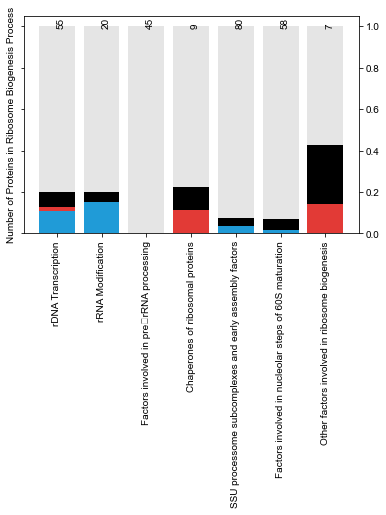

In [11]:
## Right now this looks at each protein as one so if had two idrs that each had a top feature would only pick the top IDR
mysorteduniccgeneralprocess=['rDNA Transcription','rRNA Modification','Factors involved in pre‐rRNA processing','Chaperones of ribosomal proteins','SSU processome subcomplexes and early assembly factors','Factors involved in nucleolar steps of 60S maturation', 'Other factors involved in ribosome biogenesis']

f = plt.figure()
ax = f.add_subplot(111)
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('both')

count0=[]
count1=[]
count2=[]
count3=[]
for s in range(0,len(mysorteduniccgeneralprocess)):
    count=np.zeros((len(sortbyval)+1))
    print(mysorteduniccgeneralprocess[s])
    pos=[i for i, x in enumerate(ccgeneralprocess) if x==mysorteduniccgeneralprocess[s]]
    print(len(pos))

    for p in pos:
        curracc=ccacc[p]
        tmpidx=[100, 100, 100]
        for v in range(0,len(sortbyval)):
            if curracc in topunibytype[v]:
                tmpidx[v]=topunibytype[v].index(curracc)
                print(sortbyval[v])
                print(topgenesbytype[v][tmpidx[v]]+': '+str(tmpidx[v]+1))
        minidx=tmpidx.index(min(tmpidx))
        if tmpidx[minidx]==100:
            count[len(sortbyval)]=count[len(sortbyval)]+1
        else:
            count[minidx]=count[minidx]+1

    print(count)
    count0.append(count[0])
    count1.append(count[1])
    count2.append(count[2])
    count3.append(count[3])
    print(str(sum(count))+'='+str(len(pos)))
    count=count/sum(count)

    plt.bar(s, count[0], color='#209bd7')
    plt.bar(s, count[1], bottom=count[0], color='#e23a36')
    plt.bar(s, count[2], bottom=count[0]+count[1], color='#000000')
    plt.bar(s, count[3], bottom=count[0]+count[1]+count[2], color='#e5e5e5')
    plt.text(s,sum(count),len(pos),rotation=90)
    
    
plt.xticks(np.arange(0,len(mysorteduniccgeneralprocess),1),mysorteduniccgeneralprocess,rotation=90)
plt.ylabel('Fraction of Proteins in Ribosome Biogenesis Process')
#plt.savefig('Figures/2024_02/top_idrs_sorted_all_locations/All_sapien_IDRs_fraction_exceptional_by_ribosome_biogenesis_process.pdf', transparent=True, bbox_inches = "tight") 

plt.ylabel('Number of Proteins in Ribosome Biogenesis Process')
#plt.savefig('Figures/2024_02/top_idrs_sorted_all_locations/All_sapien_IDRs_number_exceptional_by_ribosome_biogenesis_process.pdf', transparent=True, bbox_inches = "tight") 

tmpdf=pd.DataFrame()
tmpdf['Process']=mysorteduniccgeneralprocess
tmpdf[sortbyval[0]]=count0
tmpdf[sortbyval[1]]=count1
tmpdf[sortbyval[2]]=count2
tmpdf['None']=count3

print(tmpdf)
#with pd.ExcelWriter('../Supplementary_Tables/Table_S2.xlsx', engine='openpyxl',mode='a') as writer:
#   tmpdf.to_excel(writer,sheet_name='Fig_S2G')

## 1.11 - Save data to excel file

In [12]:
sortbyval=['pos-pos','neg-neg','pos-neg']
topnum=80 #30 for plotting, 80 for visualization

accsbyproc=[[] for _ in range(len(mysorteduniccgeneralprocess))]
for s in range(0,len(mysorteduniccgeneralprocess)):
    #print(mysorteduniccgeneralprocess[s])
    pos=[i for i, x in enumerate(ccgeneralprocess) if x==mysorteduniccgeneralprocess[s]]
    for p in pos:
        accsbyproc[s].append(ccacc[p])

topgenesbytype=[[] for _ in range(len(sortbyval))]
topunibytype=[[] for _ in range(len(sortbyval))]
for v in range(0,len(sortbyval)):
    print(sortbyval[v])
    dfrichsorted = dfrich.sort_values(by=sortbyval[v], ascending=False)


    topidrsval=dfrichsorted[sortbyval[v]].tolist()[:topnum]
    topidrsgene=dfrichsorted['Gene'].tolist()[:topnum]
    topidrsuni=dfrichsorted['Uniprot'].tolist()[:topnum]
    topidrslen=dfrichsorted['IDR Length'].tolist()[:topnum]
    
    topidrproc=[]
    for i in range(0,len(topidrsuni)):
        whichproc=[]
        for s in range(0,len(mysorteduniccgeneralprocess)):
            if topidrsuni[i] in accsbyproc[s]:
                whichproc.append(mysorteduniccgeneralprocess[s])
                
        if len(whichproc)==1:
            topidrproc.append(whichproc[0])
        elif len(whichproc)>1:
            topidrproc.append(', '.join(whichproc))
        else:
            topidrproc.append('')
    

    topidrsdf=pd.DataFrame()
    topidrsdf['Uniprot']=topidrsuni
    topidrsdf['Gene']=topidrsgene
    topidrsdf['IDR Length']=topidrslen
    topidrsdf[sortbyval[v]]=topidrsval
    topidrsdf['Process']=topidrproc
    print(topidrsdf)

    #with pd.ExcelWriter('../Supplementary_Tables/Table_S2.xlsx', engine='openpyxl',mode='a') as writer:
    #    topidrsdf.to_excel(writer,sheet_name='top_'+str(topnum)+'_'+sortbyval[v])


pos-pos
   Uniprot          Gene  IDR Length   pos-pos             Process
0   Q3B726   POLR1F IDR1         132  8.691213  rDNA Transcription
1   Q9UGU5   HMGXB4 IDR1         388  7.996492                    
2   Q9H7N4    SCAF1 IDR4         722  7.815823                    
3   Q5M9Q1    NKAPL IDR2         197  7.461727                    
4   O15446   POLR1G IDR4         311  7.096490  rDNA Transcription
..     ...           ...         ...       ...                 ...
75  Q8TDI0     CHD5 IDR2         118  4.611376                    
76  O75400  PRPF40A IDR4         158  4.599887                    
77  P29973    CNGA1 IDR1         128  4.585182                    
78  Q6NWY9  PRPF40B IDR4         185  4.570369                    
79  Q7Z4V5   HDGFL2 IDR1         396  4.567597                    

[80 rows x 5 columns]
neg-neg
   Uniprot           Gene  IDR Length    neg-neg  \
0   P19338       NCL IDR1         304  23.807065   
1   Q8IZL8     PELP1 IDR2         495  14.981907   
2

## 1.12 - Get top x IDRs with a given grammar feature

In [13]:
#curraa='R'
#sortbyval='Num '+curraa
#sortbyval='Cumulative Patch '+curraa
sortbyval='pos-neg'
topnum=30 #30 for plotting, 80 for visualization

dfrichsorted = dfrich.sort_values(by=[sortbyval], ascending=False)
print(dfrichsorted.head(topnum))

topidrsval=dfrichsorted[sortbyval].tolist()[:topnum]
topidrsgene=dfrichsorted['Gene'].tolist()[:topnum]
topidrsuni=dfrichsorted['Uniprot'].tolist()[:topnum]
topidrslen=dfrichsorted['IDR Length'].tolist()[:topnum]

print(dfrichsorted[['Gene',sortbyval]].head(topnum))

               Gene  Cluster                                    Location  \
16552      NCL IDR1       18         Nucleoli, Nucleoli rim, Nucleoplasm   
12078    ATAD2 IDR3       18                                 Nucleoplasm   
12379     BPTF IDR1        2                                 Nucleoplasm   
7300    ZBTB47 IDR2        7                                 Nucleoplasm   
251      KAT6B IDR5       18                 Nuclear bodies, Nucleoplasm   
23188     RSF1 IDR5       18                                 Nucleoplasm   
11280    BAZ1B IDR5       18                                 Nucleoplasm   
1156     EHMT2 IDR2       18               Nuclear speckles, Nucleoplasm   
20609    KAT6A IDR2       18                            Nuclear speckles   
22812    BAZ1A IDR5       18                                               
3688    PLPPR3 IDR2       13                             Golgi apparatus   
20369    TCOF1 IDR1        8         Nucleoli, Nucleoli fibrillar center   
4954      NP

## 1.13 - Plot sorted IDRs by grammar feature for all IDRs

Text(0.5, 0, 'Rank Order')

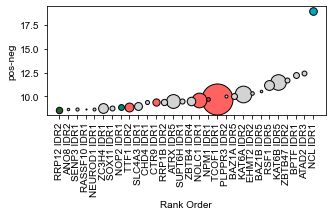

In [14]:
mygeneralcolors={'rDNA Transcription':'#ff6361', 'rRNA Modification':'#872f74', 'Factors involved in pre‐rRNA processing':'#3d2663', 'Chaperones of ribosomal proteins':'#cb3f73', 'SSU processome subcomplexes and early assembly factors':'#276026','Factors involved in nucleolar steps of 60S maturation':'#008770', 'Other factors involved in ribosome biogenesis':'#00aabe'}

plt.figure(figsize=(5,2))

tmp = np.argsort(topidrslen)
sort_index2 = tmp[::-1] 

for s in sort_index2:
    if topidrsuni[s] in ccacc:
        myidx=ccacc.index(topidrsuni[s])
        mycurrcolor=mygeneralcolors[ccgeneralprocess[myidx]]
        plt.plot(topnum-s+1,topidrsval[s],'o',markersize=(topidrslen[s])/40,markerfacecolor=mycurrcolor,markeredgecolor='black')
    else:
        plt.plot(topnum-s+1,topidrsval[s],'o',markersize=(topidrslen[s])/40,markerfacecolor='lightgrey',markeredgecolor='black')
    
plt.xticks(np.arange(len(topidrsgene)+1,1,-1),topidrsgene,rotation=90)

plt.ylabel(sortbyval)
plt.xlabel('Rank Order')

#plt.savefig('Figures/2024_02/top_idrs_sorted_all_locations/All_sapien_IDRs_feature_'+sortbyval+'_w_ribosome_biogenesis_process_reversed.pdf', transparent=True, bbox_inches = "tight") 


# Part 2: Statistical analysis of high scoring features

## 2.1 - Analysis in terms of IDRs

In [20]:
sortbyvallist=['pos-pos','neg-neg','pos-neg']
mysorteduniccgeneralprocess=['rDNA Transcription','rRNA Modification','Factors involved in pre‐rRNA processing','Chaperones of ribosomal proteins','SSU processome subcomplexes and early assembly factors','Factors involved in nucleolar steps of 60S maturation', 'Other factors involved in ribosome biogenesis']
mysorteduniccgeneralprocesswloc=['Nucleoli']+mysorteduniccgeneralprocess
topnum=80

pvalsbylocation=np.zeros((len(mysorteduniccgeneralprocess)+1,len(sortbyvallist)))
pvalsbylocation[:]=np.nan

pvalsbylocationlog=np.zeros((len(mysorteduniccgeneralprocess)+1,len(sortbyvallist)))
pvalsbylocationlog[:]=np.nan

for f in range(0,len(sortbyvallist)):
    print(sortbyvallist[f])
    ## Get information for topnum sequences
    dfrichsorted = dfrich.sort_values(by=[sortbyvallist[f]], ascending=False)
    topidrsuniwnum=dfrichsorted['Uniprot w Num'].tolist()[:topnum]
    count=0
    
    ## Get enrichment of top genes based just on location
    subfeatureyes=0
    subfeatureno=0
    restfeatureyes=0
    restfeatureno=0
    sumallidrs=0
    for s in range(0,len(fullaccs)):
        if 'Nucleoli' in fulllocationbyunistring[s]:
            if fullaccswnums[s] in topidrsuniwnum:
                subfeatureyes=subfeatureyes+1
                sumallidrs=sumallidrs+1
            else:
                subfeatureno=subfeatureno+1
        else:
            if fullaccswnums[s] in topidrsuniwnum:
                restfeatureyes=restfeatureyes+1
            else:
                restfeatureno=restfeatureno+1

    print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

    # defining the table
    if subfeatureyes+restfeatureyes>0:
        data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
        print(data)
        # One-sided greater used to test if greater occurrence in nucleolus
        res = fisher_exact(data, alternative='greater')
        print(res[1])
        pvalsbylocation[count,f]=res[1]
        if res[1]>0:
            pvalsbylocationlog[count,f]=-math.log10(res[1])
        else:
            pvalsbylocationlog[count,f]=500
            
    ## Get enrichment of top genes based on core function
    for c in range(0,len(mysorteduniccgeneralprocess)):
        count=count+1
        pos=[i for i, x in enumerate(ccgeneralprocess) if x==mysorteduniccgeneralprocess[c]]
        
        ccgeneralprocessaccs=[]
        for p in pos:
            ccgeneralprocessaccs.append(ccacc[p])

        subfeatureyes=0
        subfeatureno=0
        restfeatureyes=0
        restfeatureno=0
        sumallidrs=0
        for s in range(0,len(fullaccs)):
            if fullaccs[s] in ccgeneralprocessaccs:
                if fullaccswnums[s] in topidrsuniwnum:
                    subfeatureyes=subfeatureyes+1
                    sumallidrs=sumallidrs+1
                else:
                    subfeatureno=subfeatureno+1
            else:
                if fullaccswnums[s] in topidrsuniwnum:
                    restfeatureyes=restfeatureyes+1
                else:
                    restfeatureno=restfeatureno+1

        print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

        # defining the table
        if subfeatureyes+restfeatureyes>0:
            data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
            print(data)
            # One-sided greater used to test if greater occurrence in nucleolus
            res = fisher_exact(data, alternative='greater')
            print(res[1])
            pvalsbylocation[count,f]=res[1]
            if res[1]>0:
                pvalsbylocationlog[count,f]=-math.log10(res[1])
            else:
                pvalsbylocationlog[count,f]=500

print(pvalsbylocationlog)

pos-pos
24508
[[19, 1404], [61, 23024]]
1.1237998778207986e-07
24508
[[7, 66], [73, 24362]]
4.138374972048733e-09
24508
[[3, 12], [77, 24416]]
1.481374232820615e-05
24508
[[0, 58], [80, 24370]]
1.0
24508
[[0, 9], [80, 24419]]
1.0
24508
[[3, 132], [77, 24296]]
0.009862097470824081
24508
[[1, 94], [79, 24334]]
0.267438687113641
24508
[[0, 31], [80, 24397]]
1.0
neg-neg
24508
[[10, 1413], [70, 23015]]
0.017192745243022337
24508
[[4, 69], [76, 24359]]
9.654119511391368e-05
24508
[[0, 15], [80, 24413]]
1.0
24508
[[0, 58], [80, 24370]]
1.0
24508
[[2, 7], [78, 24421]]
0.00037322306432277633
24508
[[0, 135], [80, 24293]]
1.0
24508
[[1, 94], [79, 24334]]
0.267438687113641
24508
[[2, 29], [78, 24399]]
0.004601586527145573
pos-neg
24508
[[16, 1407], [64, 23021]]
1.2100461214979629e-05
24508
[[8, 65], [72, 24363]]
1.0194985019953544e-10
24508
[[1, 14], [79, 24414]]
0.047873837100597116
24508
[[0, 58], [80, 24370]]
1.0
24508
[[1, 8], [79, 24420]]
0.029002152236862498
24508
[[3, 132], [77, 24296]]
0.

([<matplotlib.axis.XTick at 0x150d0769ab10>,
 [Text(0.5, 0, 'pos-pos'), Text(1.5, 0, 'neg-neg'), Text(2.5, 0, 'pos-neg')])

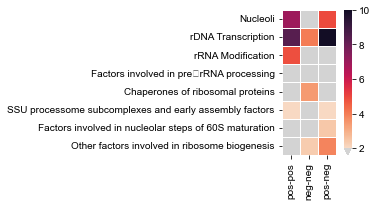

In [21]:
minpval=0.01

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (3, len(mysorteduniccgeneralprocesswloc)/3)) 
sbn.heatmap(pvalsbylocationlog,cmap=green,vmin=-math.log10(minpval), vmax=10, cbar_kws={'extend': 'min'}, square=True, linewidth=1,annot=False,fmt='.0f')
plt.yticks(np.arange(0.5, len(mysorteduniccgeneralprocesswloc), 1), mysorteduniccgeneralprocesswloc,rotation=0) 
plt.xticks(np.arange(0.5, len(sortbyvallist), 1), sortbyvallist,rotation=90) 

#plt.savefig('../../Figures/2025_04/All_sapien_IDRs_top_'+str(topnum)+'_enrichment_location_and_ribosome_biogenesis_process.pdf', transparent=True, bbox_inches = "tight") 


## 2.2 - Analysis in terms of IDR containing proteins - this is what is used in the paper

In [15]:
sortbyvallist=['pos-pos','neg-neg','pos-neg']
mysorteduniccgeneralprocess=['rDNA Transcription','rRNA Modification','Factors involved in pre‐rRNA processing','Chaperones of ribosomal proteins','SSU processome subcomplexes and early assembly factors','Factors involved in nucleolar steps of 60S maturation', 'Other factors involved in ribosome biogenesis']
mysorteduniccgeneralprocesswloc=['Nucleoli']+mysorteduniccgeneralprocess
topnum=80
unifullaccs=list(set(fullaccs))

pvalsbylocation=np.zeros((len(mysorteduniccgeneralprocess)+1,len(sortbyvallist)))
pvalsbylocation[:]=np.nan

pvalsbylocationlog=np.zeros((len(mysorteduniccgeneralprocess)+1,len(sortbyvallist)))
pvalsbylocationlog[:]=np.nan

oddsratiobylocation=np.zeros((len(mysorteduniccgeneralprocess)+1,len(sortbyvallist)))
oddsratiobylocation[:]=np.nan

for f in range(0,len(sortbyvallist)):
    print(sortbyvallist[f])
    ## Get information for topnum sequences
    dfrichsorted = dfrich.sort_values(by=[sortbyvallist[f]], ascending=False)
    topidrsuniwnum=dfrichsorted['Uniprot w Num'].tolist()[:topnum]
    count=0
    
    ## Get enrichment of top genes based just on location
    subfeatureyes=0
    subfeatureno=0
    restfeatureyes=0
    restfeatureno=0
    sumallidrs=0
    for s in range(0,len(unifullaccs)):
        idx=[i for i, x in enumerate(fullaccs) if x==unifullaccs[s]]
        counttop=0
        for i in idx:
            if fullaccswnums[i] in topidrsuniwnum:
                counttop=counttop+1
        if 'Nucleoplasm' in fulllocationbyunistring[idx[0]]:
            if counttop>0:
                subfeatureyes=subfeatureyes+1
                sumallidrs=sumallidrs+1
            else:
                subfeatureno=subfeatureno+1
        else:
            if counttop>0:
                restfeatureyes=restfeatureyes+1
            else:
                restfeatureno=restfeatureno+1

    print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

    # defining the table
    if subfeatureyes+restfeatureyes>0:
        data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
        print(data)
        # One-sided greater used to test if greater occurrence in nucleolus
        res = fisher_exact(data, alternative='greater')
        print(res[1])
        pvalsbylocation[count,f]=res[1]
        oddsratiobylocation[count,f]=res[0]
        if res[1]>0:
            pvalsbylocationlog[count,f]=-math.log10(res[1])
        else:
            pvalsbylocationlog[count,f]=500
            
    ## Get enrichment of top genes based on core function
    for c in range(0,len(mysorteduniccgeneralprocess)):
        count=count+1
        pos=[i for i, x in enumerate(ccgeneralprocess) if x==mysorteduniccgeneralprocess[c]]
        
        ccgeneralprocessaccs=[]
        for p in pos:
            ccgeneralprocessaccs.append(ccacc[p])

        subfeatureyes=0
        subfeatureno=0
        restfeatureyes=0
        restfeatureno=0
        sumallidrs=0
        for s in range(0,len(unifullaccs)):
            idx=[i for i, x in enumerate(fullaccs) if x==unifullaccs[s]]
            counttop=0
            for i in idx:
                if fullaccswnums[i] in topidrsuniwnum:
                    counttop=counttop+1
                    
            if fullaccs[idx[0]] in ccgeneralprocessaccs:
                if counttop>0:
                    subfeatureyes=subfeatureyes+1
                    sumallidrs=sumallidrs+1
                else:
                    subfeatureno=subfeatureno+1
            else:
                if counttop>0:
                    restfeatureyes=restfeatureyes+1
                else:
                    restfeatureno=restfeatureno+1

        print(subfeatureyes+subfeatureno+restfeatureyes+restfeatureno)

        # defining the table
        if subfeatureyes+restfeatureyes>0:
            data = [[subfeatureyes, subfeatureno], [restfeatureyes, restfeatureno]]
            print(data)
            # One-sided greater used to test if greater occurrence in nucleolus
            res = fisher_exact(data, alternative='greater')
            print(res[1])
            pvalsbylocation[count,f]=res[1]
            oddsratiobylocation[count,f]=res[0]
            if res[1]>0:
                pvalsbylocationlog[count,f]=-math.log10(res[1])
            else:
                pvalsbylocationlog[count,f]=500

print(pvalsbylocationlog)

pos-pos
10686
[[37, 3251], [42, 7356]]
0.0019044077513683377
10686
[[7, 31], [72, 10576]]
9.665229331946145e-09
10686
[[3, 10], [76, 10597]]
0.00010545095428863913
10686
[[0, 25], [79, 10582]]
1.0
10686
[[0, 7], [79, 10600]]
1.0
10686
[[3, 57], [76, 10550]]
0.009836109774670448
10686
[[1, 48], [78, 10559]]
0.30539884934356926
10686
[[0, 6], [79, 10601]]
1.0
neg-neg
10686
[[40, 3248], [40, 7358]]
0.00024080139389192945
10686
[[4, 34], [76, 10572]]
0.00017716352268336427
10686
[[0, 13], [80, 10593]]
1.0
10686
[[0, 25], [80, 10581]]
1.0
10686
[[2, 5], [78, 10601]]
0.0011343932525737575
10686
[[0, 60], [80, 10546]]
1.0
10686
[[1, 48], [79, 10558]]
0.3086076224514989
10686
[[2, 4], [78, 10602]]
0.0008142352519026436
pos-neg
10686
[[38, 3250], [42, 7356]]
0.0012033704049361302
10686
[[8, 30], [72, 10576]]
2.8141969669094797e-10
10686
[[1, 12], [79, 10594]]
0.09311972027399303
10686
[[0, 25], [80, 10581]]
1.0
10686
[[1, 6], [79, 10600]]
0.05125668176553657
10686
[[3, 57], [77, 10549]]
0.01017

In [16]:
#np.savetxt('data/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process.txt', pvalsbylocationlog)
#np.savetxt('data/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process_odds_ratio.txt', oddsratiobylocation)

                                             Process   pos-pos   neg-neg  \
0                                           Nucleoli  2.720240  3.618341   
1                                 rDNA Transcription  8.014788  3.751626   
2                                  rRNA Modification  3.976949 -0.000000   
3            Factors involved in pre‐rRNA processing -0.000000 -0.000000   
4                   Chaperones of ribosomal proteins -0.000000  2.945236   
5  SSU processome subcomplexes and early assembly...  2.007177 -0.000000   
6  Factors involved in nucleolar steps of 60S mat...  0.515133  0.510593   
7      Other factors involved in ribosome biogenesis -0.000000  3.089250   

    pos-neg  
0  2.919601  
1  9.550646  
2  1.030958  
3 -0.000000  
4  1.290250  
5  1.992292  
6  2.235692  
7  5.099542  


/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/events.py:88: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  func(*args, **kwargs)
/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


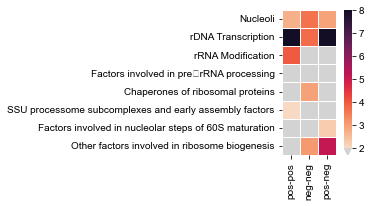

In [22]:
minpval=0.01

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (3, len(mysorteduniccgeneralprocesswloc)/3)) 
sbn.heatmap(pvalsbylocationlog,cmap=green,vmin=-math.log10(minpval), vmax=8, cbar_kws={'extend': 'min'}, square=True, linewidth=1,annot=False,fmt='.0f')
plt.yticks(np.arange(0.5, len(mysorteduniccgeneralprocesswloc), 1), mysorteduniccgeneralprocesswloc,rotation=0) 
plt.xticks(np.arange(0.5, len(sortbyvallist), 1), sortbyvallist,rotation=90) 

#plt.savefig('../../Figures/2025_04/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process.pdf', transparent=True, bbox_inches = "tight") 

[[ 2.72024006  3.618341    2.91960067]
 [ 8.01478784  3.75162569  9.55064551]
 [ 3.97694949 -0.          1.03095834]
 [-0.         -0.         -0.        ]
 [-0.          2.94523637  1.29024951]
 [ 2.00717663 -0.          1.99229152]
 [ 0.5151326   0.51059335  2.23569244]
 [-0.          3.0892501   5.09954207]]
                                             Process   pos-pos   neg-neg  \
0                                           Nucleoli  2.720240  3.618341   
1                                 rDNA Transcription  8.014788  3.751626   
2                                  rRNA Modification  3.976949 -0.000000   
3            Factors involved in pre‐rRNA processing -0.000000 -0.000000   
4                   Chaperones of ribosomal proteins -0.000000  2.945236   
5  SSU processome subcomplexes and early assembly...  2.007177 -0.000000   
6  Factors involved in nucleolar steps of 60S mat...  0.515133  0.510593   
7      Other factors involved in ribosome biogenesis -0.000000  3.089250   

  

/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/events.py:88: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  func(*args, **kwargs)
/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


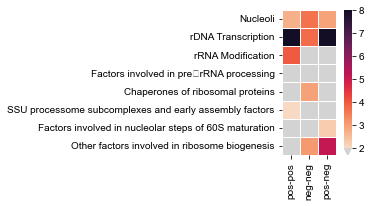

In [17]:
tmp=np.loadtxt('data/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process.txt')
print(tmp)

minpval=0.01

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

## If want to look at all 90 features
fig, ax = plt.subplots(figsize = (3, len(mysorteduniccgeneralprocesswloc)/3)) 
sbn.heatmap(tmp,cmap=green,vmin=-math.log10(minpval), vmax=8, cbar_kws={'extend': 'min'}, square=True, linewidth=1,annot=False,fmt='.0f')
plt.yticks(np.arange(0.5, len(mysorteduniccgeneralprocesswloc), 1), mysorteduniccgeneralprocesswloc,rotation=0) 
plt.xticks(np.arange(0.5, len(sortbyvallist), 1), sortbyvallist,rotation=90) 

#plt.savefig('../../Figures/2025_04/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process.pdf', transparent=True, bbox_inches = "tight") 

tdf1=pd.DataFrame(mysorteduniccgeneralprocesswloc,columns=['Process'])
tdf2=pd.DataFrame(tmp,columns=sortbyvallist)
tdf=pd.concat([tdf1,tdf2],axis=1)

print(tdf)

#tdf.to_excel('data/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process.xlsx')

                                             Process   pos-pos  \
0                                           Nucleoli  2.720240   
1                                 rDNA Transcription  8.014788   
2                                  rRNA Modification  3.976949   
3            Factors involved in pre‐rRNA processing -0.000000   
4                   Chaperones of ribosomal proteins -0.000000   
5  SSU processome subcomplexes and early assembly...  2.007177   
6  Factors involved in nucleolar steps of 60S mat...  0.515133   
7      Other factors involved in ribosome biogenesis -0.000000   

   pos-pos Odds Ratio   neg-neg  neg-neg Odds Ratio   pos-neg  \
0            1.993321  3.618341            2.265394  2.919601   
1           33.168459  3.751626           16.365325  9.550646   
2           41.830263 -0.000000            0.000000  1.030958   
3            0.000000 -0.000000            0.000000 -0.000000   
4            0.000000  2.945236           54.364103  1.290250   
5            7.

NameError: name 'hi' is not defined

/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/events.py:88: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  func(*args, **kwargs)
/project/engineering/anaconda3/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 8208 (\N{HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


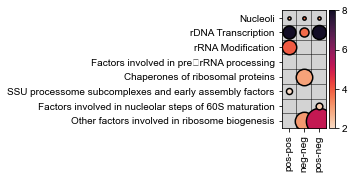

In [31]:
tmp=np.loadtxt('data/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process.txt')
tmpor=np.loadtxt('data/All_sapien_IDRs_top_'+str(topnum)+'_in_unique_IDR_containing_proteins_enrichment_location_and_ribosome_biogenesis_process_odds_ratio.txt')

minpval=0.01

c = sbn.color_palette('rocket_r', 20)
green = mpl.colors.LinearSegmentedColormap.from_list('alex_lv', c)
green.set_under(alpha=0)
green.set_under('lightgrey')

# Create data frame of processes and grammar features
dfenrichproc=pd.DataFrame()
dfenrichproc['Process']=mysorteduniccgeneralprocesswloc

for i in range(0,len(sortbyvallist)):
    dfenrichproc[sortbyvallist[i]]=tmp[:,i]
    dfenrichproc[sortbyvallist[i]+' Odds Ratio']=tmpor[:,i]
    
print(dfenrichproc)

szscale=5
fig, ax = plt.subplots(figsize=((len(sortbyvallist))/3,len(mysorteduniccgeneralprocesswloc)/3.7))
ax.set_facecolor('lightgrey')
for a in range(0,len(mysorteduniccgeneralprocesswloc)):
    ax.plot([-0.5,len(sortbyvallist)-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=-1,linewidth=0.5)
    #ax.plot([-1.5,-0.5],[-1*a-0.5,-1*a-0.5],'-',color='black',zorder=0,linewidth=0.5)
    for c in range(0,len(sortbyvallist)):
        if a==0:
            ax.plot([c+0.5,c+0.5],[0.5,-1*(len(mysorteduniccgeneralprocesswloc))+0.5],'-',color='black',zorder=0,linewidth=0.5)
            
        # Plot enrichment of IDRs of a given cluster in a pathway
        if dfenrichproc[sortbyvallist[c]].tolist()[a] > -math.log10(0.01):
            if dfenrichproc[str(sortbyvallist[c])+' Odds Ratio'].tolist()[a]>25:
                myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sortbyvallist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sortbyvallist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=8,edgecolor='black',zorder=1,linewidths=1.5)
            elif dfenrichproc[str(sortbyvallist[c])+' Odds Ratio'].tolist()[a]>15:
                myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sortbyvallist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sortbyvallist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=8,edgecolor='black',zorder=2,linewidths=1.5)
                print(mysorteduniccgeneralprocesswloc[a]+' '+str(sortbyvallist[c]))
                print(dfenrichproc[str(sortbyvallist[c])+' Odds Ratio'].tolist()[a]*szscale)
            else:
                myscatter=ax.scatter(c,-1*a,s=dfenrichproc[str(sortbyvallist[c])+' Odds Ratio'].tolist()[a]*szscale,c=dfenrichproc[sortbyvallist[c]].tolist()[a],cmap=green,vmin=-math.log10(0.01),vmax=8,edgecolor='black',zorder=3,linewidths=1.5)                    

        
#plt.colorbar(myscatter,extend='min',ax=ax)
plt.colorbar(myscatter,ax=ax)
ax.set_yticks(np.arange(0, -1*(len(mysorteduniccgeneralprocesswloc)), -1), mysorteduniccgeneralprocesswloc,rotation=0) 
ax.set_xticks(np.arange(0, len(sortbyvallist), 1), sortbyvallist,rotation=90) 
ax.set_ylim([-1*(len(mysorteduniccgeneralprocesswloc))+0.5,0.5])
ax.set_xlim([-0.5,len(sortbyvallist)-0.5])
hi

size_val_arr=np.array([5,15,25])
for size_val, label_text in [(szscale*size_val_arr[0], str(size_val_arr[0])), (szscale*size_val_arr[1], str(size_val_arr[1])), (szscale*size_val_arr[2], str(size_val_arr[2]))]:
    ax.scatter([], [], s=size_val, color='gray', edgecolor='black',linewidth=1.5, alpha=0.6, label=f'{label_text}')
    print(size_val)
plt.legend(scatterpoints=1, frameon=True, title="Odds Ratio")